# 06 - Visualisation

Produces a final set of polished visualisations summarising the key 
findings of the Driver Performance Index across all five seasons.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

In [2]:
PROCESSED_DIR = Path('../data/processed')
OUTPUT_DIR    = Path('../outputs')

dpi_df      = pd.read_csv(PROCESSED_DIR / 'dpi_final.csv')
cluster_df  = pd.read_csv(PROCESSED_DIR / 'driver_season_clustered.csv')

print("DPI data shape:",     dpi_df.shape)
print("Cluster data shape:", cluster_df.shape)

DPI data shape: (105, 24)
Cluster data shape: (105, 19)


## Chart 1 - DPI Score Distribution by Performance Tier


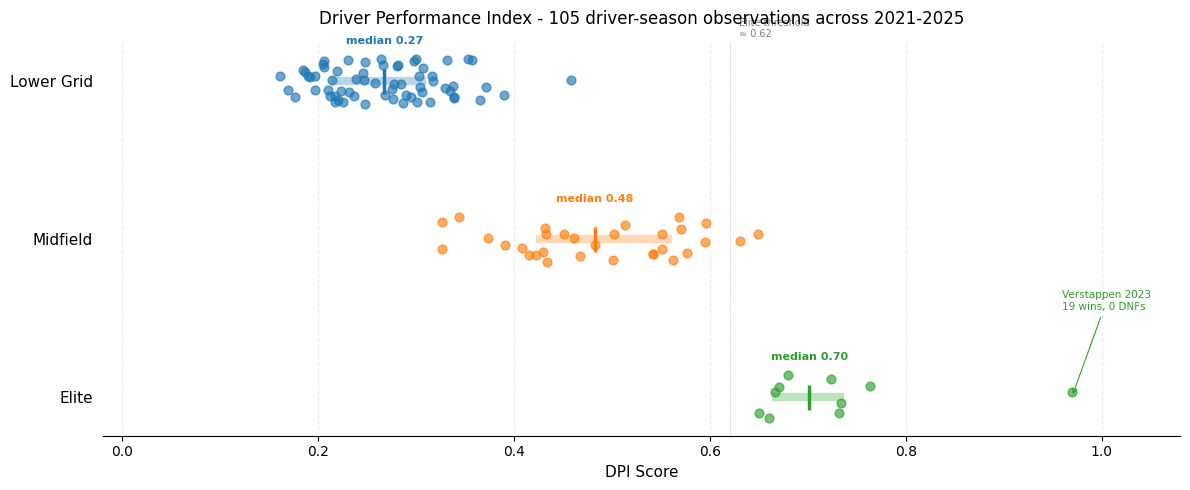

In [10]:
colour_map = {
    'Elite'      : '#2ca02c',
    'Midfield'   : '#ff7f0e',
    'Lower Grid' : '#1f77b4'
}

tier_order = ['Elite', 'Midfield', 'Lower Grid']

fig, ax = plt.subplots(figsize=(12, 5))

for i, tier in enumerate(tier_order):
    subset = dpi_df[dpi_df['cluster_label'] == tier]
    np.random.seed(42)
    jitter = np.random.uniform(-0.15, 0.15, size=len(subset))
    ax.scatter(
        subset['DPI'],
        np.full(len(subset), i) + jitter,
        color=colour_map[tier],
        alpha=0.65, s=40, zorder=3
    )
    q1, med, q3 = subset['DPI'].quantile([0.25, 0.5, 0.75])
    ax.plot([q1, q3], [i, i], color=colour_map[tier],
            linewidth=6, alpha=0.3, zorder=2)
    ax.plot(med, i, marker='|', color=colour_map[tier],
            markersize=18, markeredgewidth=2.5, zorder=4)
    ax.text(med, i + 0.22, f'median {med:.2f}',
            ha='center', va='bottom', fontsize=8,
            color=colour_map[tier], fontweight='bold')

ver23 = dpi_df[(dpi_df['driver_name'] == 'Max Verstappen') &
               (dpi_df['season'] == 2023)].iloc[0]
ax.annotate(
    'Verstappen 2023\n19 wins, 0 DNFs',
    xy=(ver23['DPI'], 0),
    xytext=(ver23['DPI'] - 0.01, 0.55),
    fontsize=7.5, color='#2ca02c',
    arrowprops=dict(arrowstyle='->', color='#2ca02c', lw=0.8)
)

ax.axvline(0.62, color='grey', linewidth=0.6,
           linestyle=':', alpha=0.6)
ax.text(0.63, 2.4, 'Elite threshold\n≈ 0.62',
        fontsize=7, color='grey', va='top')

ax.set_yticks(range(len(tier_order)))
ax.set_yticklabels(tier_order, fontsize=11)
ax.set_xlabel('DPI Score', fontsize=11)
ax.set_title(
    'Driver Performance Index - 105 driver-season observations across 2021-2025',
    fontsize=12, pad=12
)
ax.set_xlim(-0.02, 1.08)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(axis='x', alpha=0.25, linestyle='--')
ax.tick_params(left=False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dpi_distribution_by_tier.png', dpi=200, bbox_inches='tight')
plt.show()

### What this chart shows

Each point represents one driver-season observation plotted at its DPI score. The three rows correspond to the three performance tiers identified by K-Means clustering. The horizontal bar shows the interquartile range and the vertical line marks the median for each tier.

The clear separation between tiers confirms that the clustering is meaningful, there is very little overlap between Lower Grid and Midfield, and the Elite tier 
sits well above both. Verstappen's 2023 season at 0.970 is a genuine statistical outlier, sitting almost 0.2 points clear of the next Elite driver. The dotted line at 0.62 marks the approximate boundary above which the K-Means algorithm 
classified a driver-season as Elite.

## Chart 2 - Career DPI Timeline



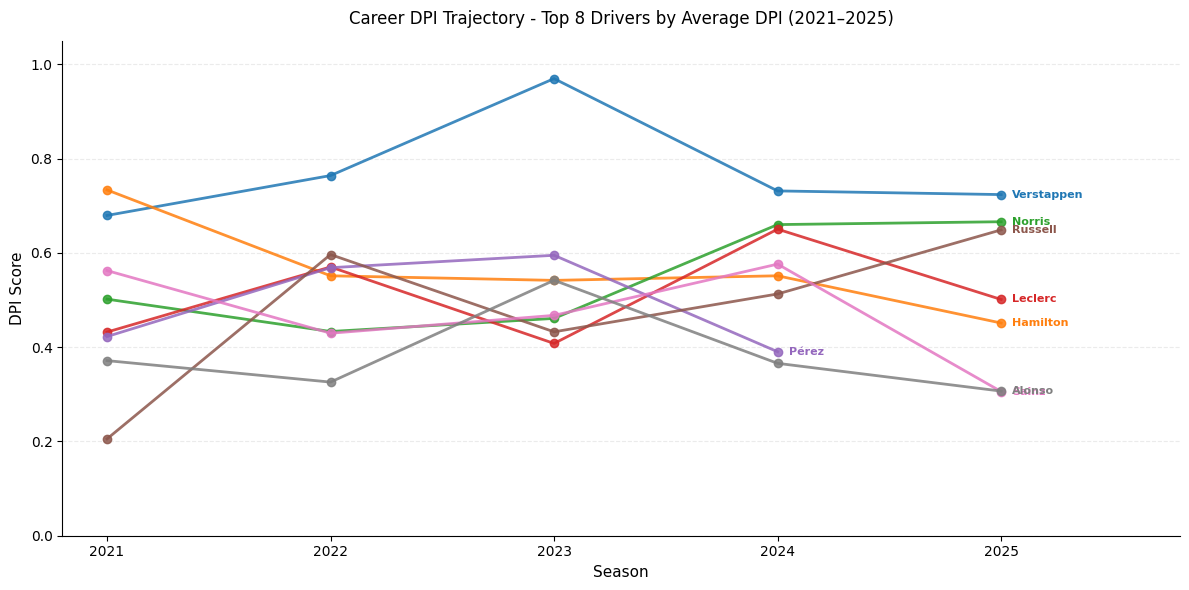

In [12]:
career_counts = dpi_df.groupby('driver_name')['season'].count()
multi_season  = career_counts[career_counts >= 4].index.tolist()

career_avg = (
    dpi_df[dpi_df['driver_name'].isin(multi_season)]
    .groupby('driver_name')['DPI'].mean()
    .sort_values(ascending=False)
    .head(8).index.tolist()
)

plot_df = dpi_df[dpi_df['driver_name'].isin(career_avg)].copy()

colours = plt.cm.tab10.colors
driver_colours = {name: colours[i] for i, name in enumerate(career_avg)}

fig, ax = plt.subplots(figsize=(12, 6))

for driver in career_avg:
    data = plot_df[plot_df['driver_name'] == driver].sort_values('season')
    ax.plot(data['season'], data['DPI'],
            marker='o', linewidth=2, markersize=6,
            color=driver_colours[driver], alpha=0.85)

    last = data.iloc[-1]
    ax.text(last['season'] + 0.05, last['DPI'],
            driver.split()[-1],  
            fontsize=8, va='center',
            color=driver_colours[driver], fontweight='bold')

ax.set_xlim(2020.8, 2025.8)
ax.set_ylim(0, 1.05)
ax.set_xticks([2021, 2022, 2023, 2024, 2025])
ax.set_xlabel('Season', fontsize=11)
ax.set_ylabel('DPI Score', fontsize=11)
ax.set_title(
    'Career DPI Trajectory - Top 8 Drivers by Average DPI (2021–2025)',
    fontsize=12, pad=12
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.25, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'career_dpi_trajectory.png', dpi=200, bbox_inches='tight')
plt.show()

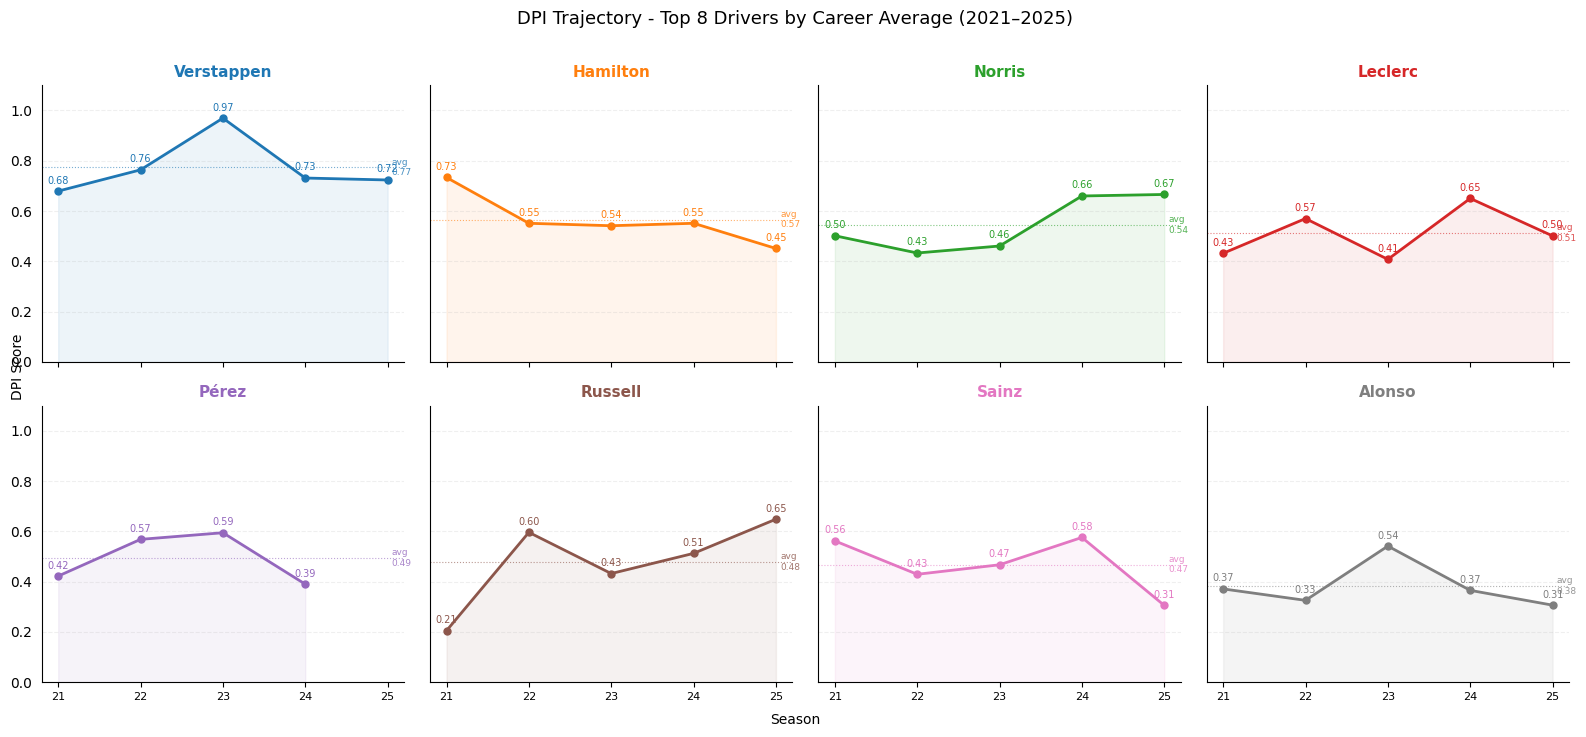

In [15]:
career_counts = dpi_df.groupby('driver_name')['season'].count()
multi_season  = career_counts[career_counts >= 4].index.tolist()

career_avg = (
    dpi_df[dpi_df['driver_name'].isin(multi_season)]
    .groupby('driver_name')['DPI'].mean()
    .sort_values(ascending=False)
    .head(8).index.tolist()
)

plot_df = dpi_df[dpi_df['driver_name'].isin(career_avg)].copy()

colours = plt.cm.tab10.colors
driver_colours = {name: colours[i] for i, name in enumerate(career_avg)}

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True, sharex=True)
axes = axes.flatten()

for i, driver in enumerate(career_avg):
    ax   = axes[i]
    data = plot_df[plot_df['driver_name'] == driver].sort_values('season')

    ax.plot(data['season'], data['DPI'],
            marker='o', linewidth=2, markersize=5,
            color=driver_colours[driver])

    ax.fill_between(data['season'], data['DPI'],
                    alpha=0.08, color=driver_colours[driver])

    for _, row in data.iterrows():
        ax.text(row['season'], row['DPI'] + 0.03,
                f"{row['DPI']:.2f}",
                ha='center', fontsize=7,
                color=driver_colours[driver])

    ax.set_title(driver.split()[-1], fontsize=11,
                 fontweight='bold', color=driver_colours[driver])
    ax.set_ylim(0, 1.1)
    ax.set_xticks([2021, 2022, 2023, 2024, 2025])
    ax.set_xticklabels(['21', '22', '23', '24', '25'], fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.2, linestyle='--')
    ax.tick_params(left=False)

    career_mean = data['DPI'].mean()
    ax.axhline(career_mean, color=driver_colours[driver],
               linewidth=0.8, linestyle=':', alpha=0.6)
    ax.text(2025.05, career_mean,
            f'avg\n{career_mean:.2f}',
            fontsize=6.5, va='center',
            color=driver_colours[driver], alpha=0.8)

fig.suptitle(
    'DPI Trajectory - Top 8 Drivers by Career Average (2021–2025)',
    fontsize=13, y=1.01
)
fig.text(0.5, -0.01, 'Season', ha='center', fontsize=10)
fig.text(0.01, 0.5, 'DPI Score', va='center',
         rotation='vertical', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'career_dpi_trajectory.png',
            dpi=200, bbox_inches='tight')
plt.show()

### What these charts show

The spaghetti chart allows direct comparison between drivers across seasons on the same axis. The small multiples show each driver's individual trajectory clearly without visual interference from other lines. The dotted reference line 
in each panel marks that driver's career average DPI.

Key stories visible in the data: Norris shows a consistent upward trajectory from 0.41 in 2022 to 0.67 in 2025, reflecting McLaren's rise as a championship 
contender. Pérez peaks in 2023 at 0.59 alongside Verstappen's dominant Red Bull season then drops sharply to 0.39 in 2024 as the car's advantage diminished and 
his performance relative to teammates declined. Hamilton shows a gradual decline from 0.73 in 2021 to 0.45 in 2025, his final season at Mercedes before moving to Ferrari. Russell improves steadily from 0.21 in 2021, his final Williams season to 0.65 in 2025 at Mercedes.

## Chart 3 - Driver Feature Radar

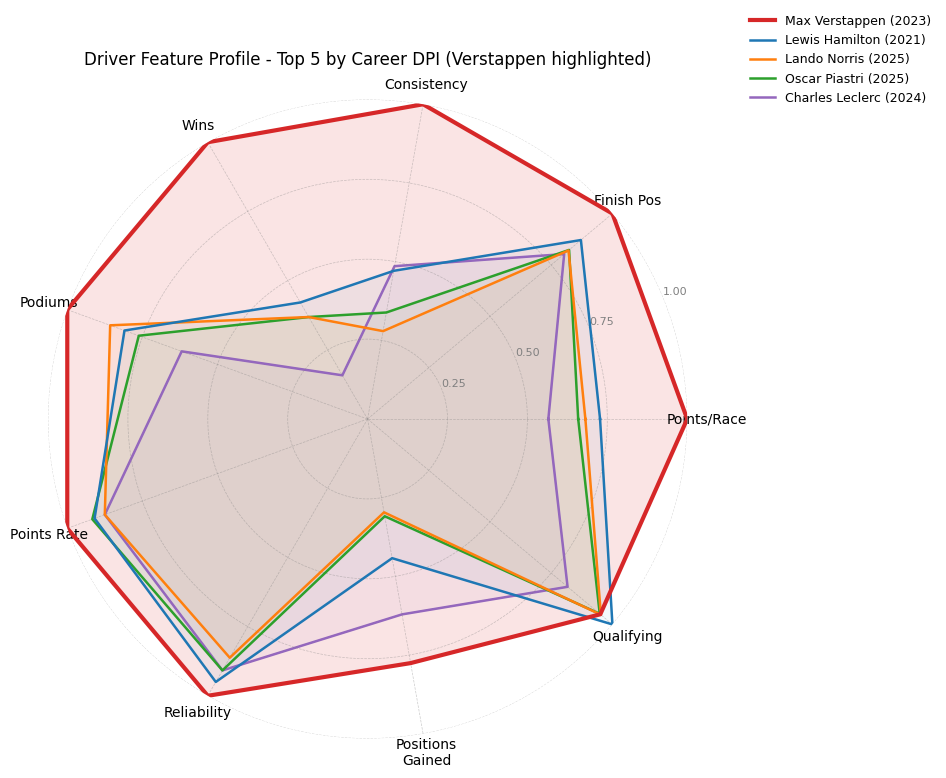

In [19]:
top5_drivers = (
    dpi_df.groupby('driver_name')['DPI'].mean()
    .sort_values(ascending=False)
    .head(5).index.tolist()
)

index_features = [
    'points_per_race', 'avg_finish_position', 'finish_position_std',
    'wins', 'podiums', 'points_finish_rate',
    'dnf_rate', 'avg_positions_gained', 'avg_quali_position'
]

feature_labels = [
    'Points/Race', 'Finish Pos', 'Consistency',
    'Wins', 'Podiums', 'Points Rate',
    'Reliability', 'Positions\nGained', 'Qualifying'
]

best_seasons = (
    dpi_df[dpi_df['driver_name'].isin(top5_drivers)]
    .sort_values('DPI', ascending=False)
    .groupby('driver_name')
    .first()
    .reset_index()
)

best_seasons['order'] = best_seasons['driver_name'].map(
    {name: i for i, name in enumerate(top5_drivers)}
)
best_seasons = best_seasons.sort_values('order')

colours    = ['#d62728','#1f77b4','#ff7f0e','#2ca02c','#9467bd']
linewidths = [3, 1.8, 1.8, 1.8, 1.8]
alphas     = [0.12, 0.05, 0.05, 0.05, 0.05]

N      = len(index_features)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10),
                       subplot_kw=dict(polar=True))

for i, (_, row) in enumerate(best_seasons.iterrows()):
    values  = row[index_features].values.tolist()
    values += values[:1]

    ax.plot(angles, values,
            linewidth=linewidths[i],
            color=colours[i],
            label=f"{row['driver_name']} ({int(row['season'])})",
            zorder=5 - i)
    ax.fill(angles, values,
            alpha=alphas[i],
            color=colours[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(feature_labels, size=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'],
                   size=8, color='grey')
ax.grid(color='grey', linestyle='--',
        linewidth=0.5, alpha=0.4)
ax.spines['polar'].set_visible(False)

ax.set_title(
    'Driver Feature Profile - Top 5 by Career DPI (Verstappen highlighted)',
    size=12, pad=25
)
ax.legend(loc='upper right',
          bbox_to_anchor=(1.4, 1.15),
          fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'radar_top5_drivers.png',
            dpi=200, bbox_inches='tight')
plt.show()
plt.show()

### What this chart shows

Each axis represents one of the nine normalised DPI features. A score of 1.0 on any axis means that driver-season achieved the best value for that 
feature across the entire dataset. Verstappen 2023 dominates almost every dimension simultaneously, the only area where other drivers compete meaningfully is Positions Gained, which reflects the racecraft dimension that is independent of outright car pace. Hamilton 2021 shows the closest 
overall profile to Verstappen, confirming how competitive that season was despite the points gap at the end. Norris and Piastri 2025 show near-identical profiles, reflecting two drivers of similar ability in the same car.

## Chart 4 - DPI Feature Contribution Breakdown


C:\Users\richy\AppData\Local\Temp\ipykernel_5648\2897256363.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab10', len(index_features))


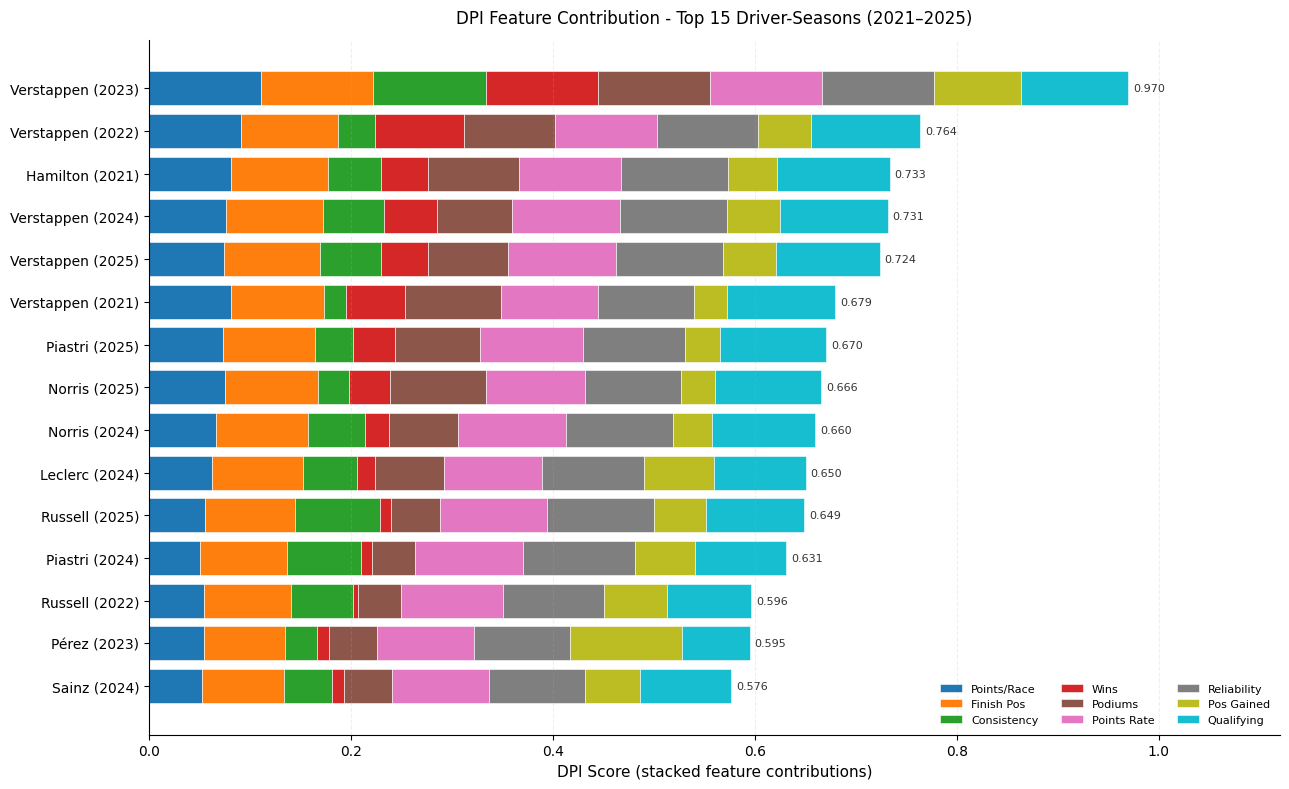

In [20]:
top15 = dpi_df.sort_values('DPI', ascending=False).head(15).copy()

weight = 1 / len(index_features)
contrib_cols = [f+'_contrib' for f in index_features]
for feat, col in zip(index_features, contrib_cols):
    top15[col] = top15[feat] * weight

labels = [
    f"{row['driver_name'].split()[-1]} ({int(row['season'])})"
    for _, row in top15.iterrows()
]

feature_display = [
    'Points/Race', 'Finish Pos', 'Consistency', 'Wins', 'Podiums',
    'Points Rate', 'Reliability', 'Pos Gained', 'Qualifying'
]

contrib_data = top15[contrib_cols].values

cmap   = plt.cm.get_cmap('tab10', len(index_features))
colours = [cmap(i) for i in range(len(index_features))]

fig, ax = plt.subplots(figsize=(13, 8))

left = np.zeros(len(top15))
for i, (feat_label, col) in enumerate(zip(feature_display, contrib_cols)):
    vals = top15[col].values
    ax.barh(labels, vals, left=left,
            color=colours[i], label=feat_label,
            edgecolor='white', linewidth=0.4)
    left += vals

for j, (_, row) in enumerate(top15.iterrows()):
    ax.text(row['DPI'] + 0.005, j,
            f"{row['DPI']:.3f}",
            va='center', fontsize=8, color='#333333')

ax.set_xlim(0, 1.12)
ax.set_xlabel('DPI Score (stacked feature contributions)', fontsize=11)
ax.set_title(
    'DPI Feature Contribution - Top 15 Driver-Seasons (2021–2025)',
    fontsize=12, pad=12
)
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.2, linestyle='--')
ax.legend(
    loc='lower right', fontsize=8,
    frameon=False, ncol=3
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_contribution_top15.png',
            dpi=200, bbox_inches='tight')
plt.show()

### What this chart shows

Each horizontal bar represents one driver-season, ordered by total DPI score. 
The segments show exactly how much each of the nine features contributes to the final score. Because equal weighting is applied, each feature can contribute a maximum of 1/9 = 0.111 to the total.

Verstappen 2023 stands out immediately, his bar extends significantly further than all others because he scored near the maximum on almost every feature simultaneously. The chart also reveals where drivers have gaps in their profile. 
Leclerc 2024 has a notably smaller Reliability segment reflecting Ferrari's higher DNF rate that season. Russell 2022 has a larger Pos Gained segment 
than most Elite-tier drivers, reflecting his ability to move through the field in a car that was not always starting from the front row.

This chart makes the equal weighting assumption transparent, the reader can see exactly what is driving each score rather than accepting a single number at face value.

## Chart 5 - Top 10 Driver-Seasons by DPI

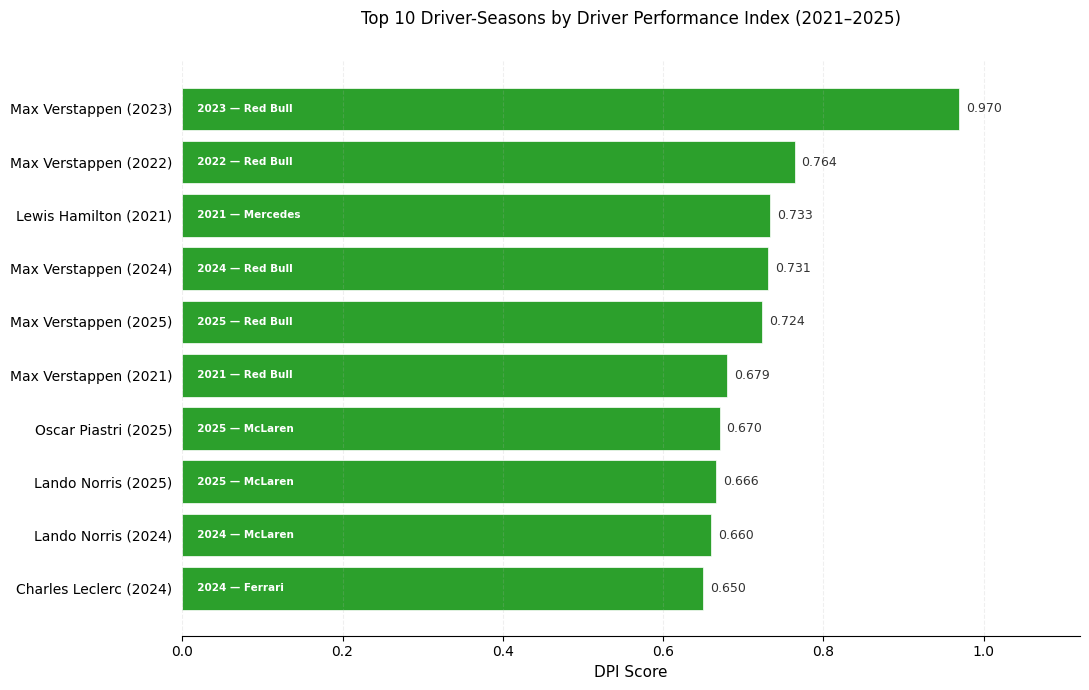

In [26]:
top10 = dpi_df.sort_values('DPI', ascending=False).head(10).copy()

tier_colours = {
    'Elite'      : '#2ca02c',
    'Midfield'   : '#ff7f0e',
    'Lower Grid' : '#1f77b4'
}

bar_colours = [tier_colours[t] for t in top10['cluster_label']]

labels = [
    f"{row['driver_name']} ({int(row['season'])})"
    for _, row in top10.iterrows()
]

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(labels, top10['DPI'],
               color=bar_colours, edgecolor='white',
               linewidth=0.5)

ax.bar_label(bars, fmt='%.3f', padding=5,
             fontsize=9, color='#333333')

for i, (_, row) in enumerate(top10.iterrows()):
    ax.text(0.01, i,
            f"  {int(row['season'])} — {row['constructor']}",
            va='center', fontsize=7.5, color='white',
            fontweight='bold')

ax.set_xlim(0, 1.12)
ax.invert_yaxis()
ax.set_xlabel('DPI Score', fontsize=11)
ax.set_title(
    'Top 10 Driver-Seasons by Driver Performance Index (2021–2025)\n',
    fontsize=12, pad=12
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(axis='x', alpha=0.2, linestyle='--')
ax.tick_params(left=False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top10_dpi_final.png',
            dpi=200, bbox_inches='tight')
plt.show()

## Chart 7 - Verstappen 2023 Lap Time Analysis (OpenF1)


In [46]:
import requests
import time

OPENF1_BASE = 'https://api.openf1.org/v1'

def openf1_get(endpoint, params=None):
    url      = f"{OPENF1_BASE}/{endpoint}"
    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    time.sleep(0.3)
    return response.json()

sessions = openf1_get('sessions', params={
    'year'         : 2023,
    'session_type' : 'Race',
    'country_name' : 'Bahrain'
})

print("Sessions found:")
for s in sessions:
    print(s)

Sessions found:
{'session_key': 7953, 'session_type': 'Race', 'session_name': 'Race', 'date_start': '2023-03-05T15:00:00+00:00', 'date_end': '2023-03-05T17:00:00+00:00', 'meeting_key': 1141, 'circuit_key': 63, 'circuit_short_name': 'Sakhir', 'country_key': 36, 'country_code': 'BRN', 'country_name': 'Bahrain', 'location': 'Sakhir', 'gmt_offset': '03:00:00', 'year': 2023, 'is_cancelled': False}


### Fetching Lap Time Data

In [47]:
SESSION_KEY = 7953

laps_raw = openf1_get('laps', params={'session_key': SESSION_KEY})
laps      = pd.DataFrame(laps_raw)

print("Columns:", list(laps.columns))
print("Shape:", laps.shape)
print("\nDrivers in session:", laps['driver_number'].unique())

Columns: ['meeting_key', 'session_key', 'driver_number', 'lap_number', 'date_start', 'duration_sector_1', 'duration_sector_2', 'duration_sector_3', 'i1_speed', 'i2_speed', 'is_pit_out_lap', 'lap_duration', 'segments_sector_1', 'segments_sector_2', 'segments_sector_3', 'st_speed']
Shape: (1058, 16)

Drivers in session: [ 1 11 16 31 27 55  4 77 14 24 22 63 23 44  2 20 18 81 10 21]


In [48]:
drivers = openf1_get('drivers', params={'session_key': SESSION_KEY})
drivers_df = pd.DataFrame(drivers)
print(drivers_df[['driver_number', 'full_name', 'team_name']])

    driver_number        full_name        team_name
0               1   Max VERSTAPPEN  Red Bull Racing
1               2   Logan SARGEANT         Williams
2               4     Lando NORRIS          McLaren
3              10     Pierre GASLY           Alpine
4              11     Sergio PEREZ  Red Bull Racing
5              14  Fernando ALONSO     Aston Martin
6              16  Charles LECLERC          Ferrari
7              18     Lance STROLL     Aston Martin
8              20  Kevin MAGNUSSEN     Haas F1 Team
9              21    Nyck DE VRIES       AlphaTauri
10             22     Yuki TSUNODA       AlphaTauri
11             23  Alexander ALBON         Williams
12             24      ZHOU Guanyu       Alfa Romeo
13             27  Nico HULKENBERG     Haas F1 Team
14             31     Esteban OCON           Alpine
15             44   Lewis HAMILTON         Mercedes
16             55     Carlos SAINZ          Ferrari
17             63   George RUSSELL         Mercedes
18          

In [49]:
laps_clean = laps.copy()
laps_clean = laps_clean.dropna(subset=['lap_duration', 'lap_number'])
laps_clean = laps_clean[laps_clean['lap_duration'] > 90]   # remove outlap/inlap
laps_clean = laps_clean[laps_clean['lap_duration'] < 120]  # remove safety car laps
laps_clean = laps_clean[laps_clean['lap_number'] > 1]      # remove formation lap

print("Clean laps shape:", laps_clean.shape)
print("Lap range:", laps_clean['lap_number'].min(),
      "to", laps_clean['lap_number'].max())

Clean laps shape: (998, 16)
Lap range: 2 to 57


### Verstappen vs Field - Lap by Lap

In [50]:
VER_NUM = 1

ver_all_laps = laps[laps['driver_number'] == VER_NUM].copy()
pit_out_laps = ver_all_laps[ver_all_laps['is_pit_out_lap'] == True]['lap_number'].tolist()
pit_in_laps  = [x - 1 for x in pit_out_laps]

pit_laps_all = pit_out_laps + pit_in_laps

print("Pit out laps:", pit_out_laps)
print("Pit in laps:", pit_in_laps)
print("All pit-related laps excluded:", sorted(pit_laps_all))

ver_laps = laps_clean[
    (laps_clean['driver_number'] == VER_NUM) &
    (~laps_clean['lap_number'].isin(pit_laps_all))
].copy()
ver_laps = ver_laps.sort_values('lap_number')

field_avg = (
    laps_clean[
        (laps_clean['driver_number'] != VER_NUM) &
        (~laps_clean['lap_number'].isin(pit_laps_all))
    ]
    .groupby('lap_number')['lap_duration']
    .median()
    .reset_index()
    .rename(columns={'lap_duration': 'field_median'})
)

merged = ver_laps.merge(field_avg, on='lap_number', how='inner')
merged['gap_to_field'] = merged['field_median'] - merged['lap_duration']

print(f"\nVerstappen average lap: {ver_laps['lap_duration'].mean():.3f}s")
print(f"Field median average:   {field_avg['field_median'].mean():.3f}s")
print(f"Average gap per lap:    {merged['gap_to_field'].mean():.3f}s faster")

Pit out laps: [15, 37]
Pit in laps: [14, 36]
All pit-related laps excluded: [14, 15, 36, 37]

Verstappen average lap: 97.610s
Field median average:   99.247s
Average gap per lap:    1.378s faster


In [51]:
ver_all = laps[laps['driver_number'] == VER_NUM].copy()
ver_all = ver_all[ver_all['lap_number'] > 1]
pit_laps = ver_all[ver_all['is_pit_out_lap'] == True]['lap_number'].tolist()
print("Pit out laps:", pit_laps)

Pit out laps: [15, 37]


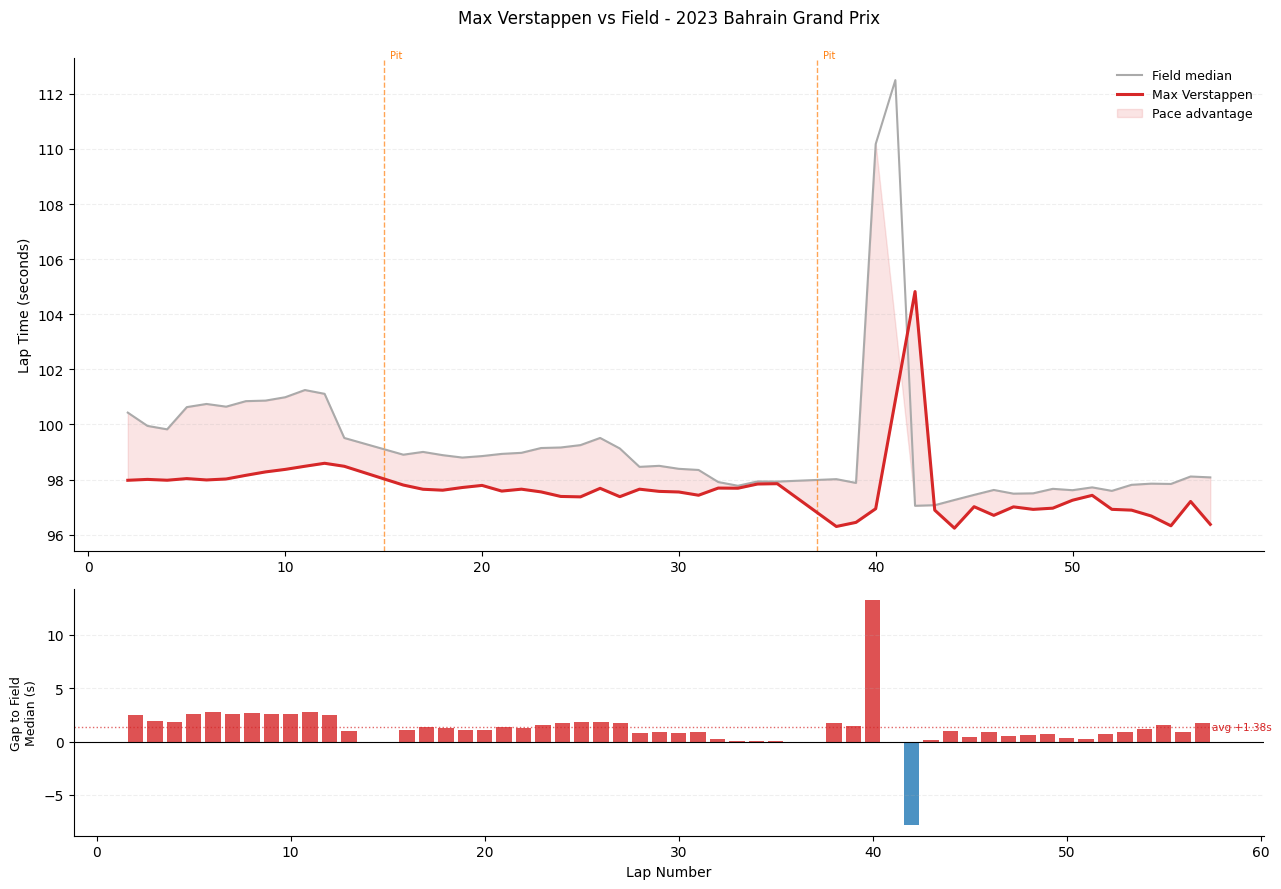

In [52]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9),
                                gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(field_avg['lap_number'], field_avg['field_median'],
         color='#aaaaaa', linewidth=1.5,
         label='Field median', zorder=2)

ax1.plot(merged['lap_number'], merged['lap_duration'],
         color='#d62728', linewidth=2.2,
         label='Max Verstappen', zorder=3)

ax1.fill_between(
    merged['lap_number'],
    merged['lap_duration'],
    merged['field_median'],
    alpha=0.12, color='#d62728',
    label='Pace advantage'
)

for pit in pit_laps:
    ax1.axvline(pit, color='#ff7f0e', linewidth=1,
                linestyle='--', alpha=0.7)
    ax1.text(pit + 0.3, ax1.get_ylim()[1] if ax1.get_ylim()[1] < 120 else 105,
             'Pit', fontsize=7, color='#ff7f0e')

ax1.set_ylabel('Lap Time (seconds)', fontsize=10)
ax1.set_title(
    'Max Verstappen vs Field - 2023 Bahrain Grand Prix\n',
    fontsize=12, pad=10
)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.2, linestyle='--')
ax1.legend(fontsize=9, frameon=False)

ax2.bar(merged['lap_number'], merged['gap_to_field'],
        color=merged['gap_to_field'].apply(
            lambda x: '#d62728' if x > 0 else '#1f77b4'),
        width=0.8, alpha=0.8)

ax2.axhline(0, color='black', linewidth=0.8)
ax2.axhline(merged['gap_to_field'].mean(),
            color='#d62728', linewidth=1,
            linestyle=':', alpha=0.7)
ax2.text(57.5, merged['gap_to_field'].mean(),
         f"avg +{merged['gap_to_field'].mean():.2f}s",
         fontsize=7.5, color='#d62728', va='center')

ax2.set_xlabel('Lap Number', fontsize=10)
ax2.set_ylabel('Gap to Field\nMedian (s)', fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'verstappen_2023_bahrain_lap_analysis.png',
            dpi=200, bbox_inches='tight')
plt.show()

### What this chart shows

Each point on the red line is Verstappen's actual lap time for that lap. The grey line is the median lap time of the remaining 19 drivers on the same lap. The shaded red area shows his pace advantage where his line sits below the field median he was faster than the typical car on track.

Pit stops are marked with dashed orange lines at laps 15 and 37. Pit in and out laps are excluded from both lines and the gap calculation to avoid distorting the pace comparison with slow pit entry and exit laps.

The bottom panel shows his gap to the field median on each racing lap. Red bars mean he was faster than the median, blue means slower. On average Verstappen was 1.38 seconds per lap faster than the field median across 55 racing laps compounded over a 57-lap race this explains his 11.9 second winning margin. The spike around lap 41 visible in both lines 
is consistent with a virtual safety car period where all drivers slowed simultaneously.

This analysis from OpenF1 telemetry directly supports the DPI finding Verstappen's 0.970 score in 2023 is not just the effort of a dominant car alone. His lap times show he had a  consistent pace advantages race by race throughout that season.

## Chart 8 - Verstappen vs Pérez: Same Car, Different Drivers


In [54]:
PER_NUM = 11

per_all_laps = laps[laps['driver_number'] == PER_NUM].copy()
per_pit_out  = per_all_laps[per_all_laps['is_pit_out_lap'] == True]['lap_number'].tolist()
per_pit_in   = [x - 1 for x in per_pit_out]
per_pit_all  = per_pit_out + per_pit_in

per_laps = laps_clean[
    (laps_clean['driver_number'] == PER_NUM) &
    (~laps_clean['lap_number'].isin(per_pit_all))
].copy()
per_laps = per_laps.sort_values('lap_number')

print(f"Verstappen pit laps: {sorted(pit_laps_all)}")
print(f"Pérez pit laps:      {sorted(per_pit_all)}")
print(f"\nVerstappen clean laps: {len(ver_laps)}")
print(f"Pérez clean laps:      {len(per_laps)}")

Verstappen pit laps: [14, 15, 36, 37]
Pérez pit laps:      [17, 18, 34, 35]

Verstappen clean laps: 51
Pérez clean laps:      51


In [55]:
comparison = ver_laps[['lap_number', 'lap_duration']].merge(
    per_laps[['lap_number', 'lap_duration']],
    on='lap_number',
    suffixes=('_ver', '_per')
)

comparison['gap'] = comparison['lap_duration_per'] - comparison['lap_duration_ver']

print(f"Laps compared: {len(comparison)}")
print(f"Verstappen average: {comparison['lap_duration_ver'].mean():.3f}s")
print(f"Pérez average:      {comparison['lap_duration_per'].mean():.3f}s")
print(f"Average gap:        {comparison['gap'].mean():.3f}s per lap")
print(f"Pérez faster laps:  {(comparison['gap'] < 0).sum()}")
print(f"Verstappen faster:  {(comparison['gap'] > 0).sum()}")

Laps compared: 47
Verstappen average: 97.599s
Pérez average:      97.745s
Average gap:        0.146s per lap
Pérez faster laps:  17
Verstappen faster:  30


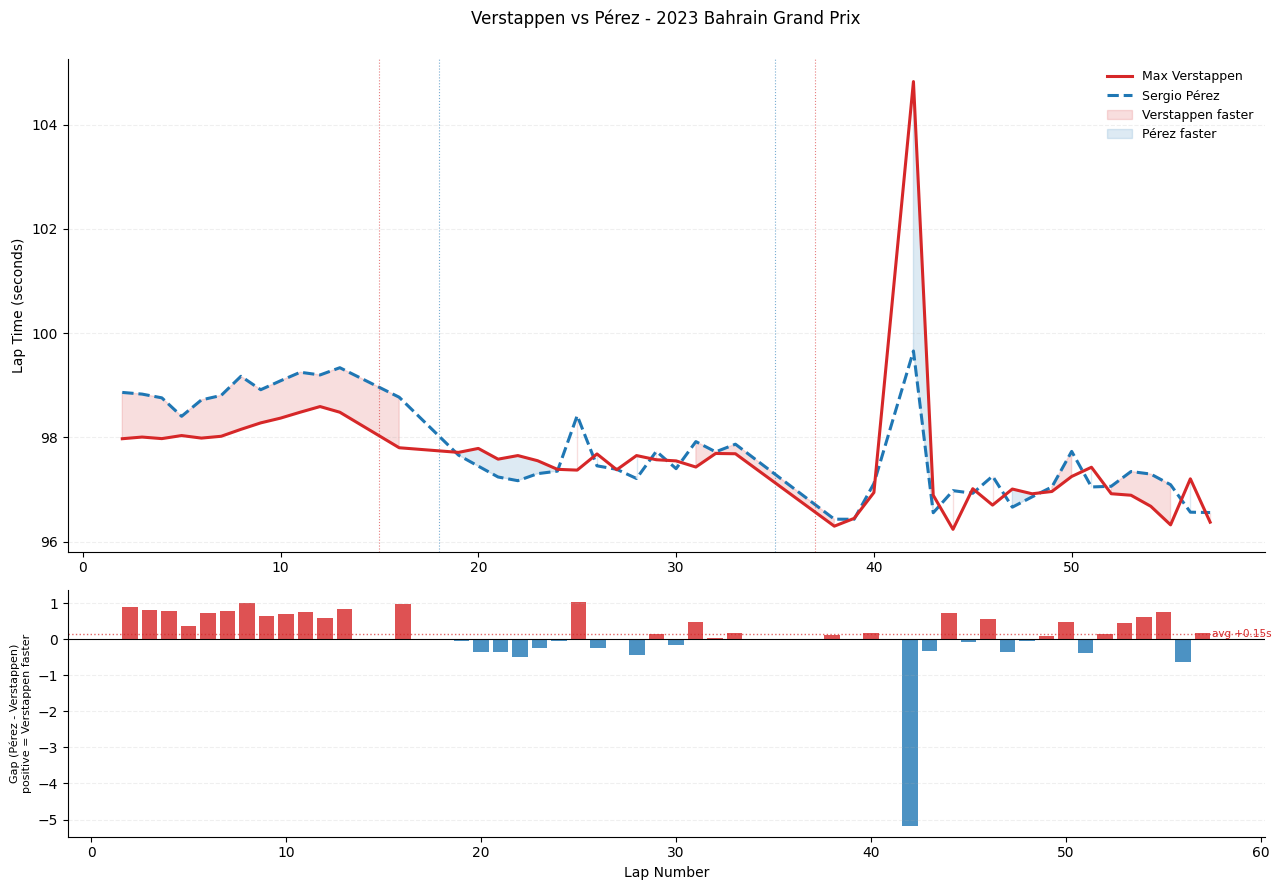

In [57]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9),
                                gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(comparison['lap_number'],
         comparison['lap_duration_ver'],
         color='#d62728', linewidth=2.2,
         label='Max Verstappen', zorder=3)

ax1.plot(comparison['lap_number'],
         comparison['lap_duration_per'],
         color='#1f77b4', linewidth=2.2,
         linestyle='--', label='Sergio Pérez', zorder=2)

ax1.fill_between(
    comparison['lap_number'],
    comparison['lap_duration_ver'],
    comparison['lap_duration_per'],
    where=comparison['lap_duration_ver'] < comparison['lap_duration_per'],
    alpha=0.15, color='#d62728', label='Verstappen faster'
)
ax1.fill_between(
    comparison['lap_number'],
    comparison['lap_duration_ver'],
    comparison['lap_duration_per'],
    where=comparison['lap_duration_ver'] > comparison['lap_duration_per'],
    alpha=0.15, color='#1f77b4', label='Pérez faster'
)

for pit in pit_out_laps:
    ax1.axvline(pit, color='#d62728', linewidth=0.8,
                linestyle=':', alpha=0.6)
for pit in per_pit_out:
    ax1.axvline(pit, color='#1f77b4', linewidth=0.8,
                linestyle=':', alpha=0.6)

ax1.set_ylabel('Lap Time (seconds)', fontsize=10)
ax1.set_title(
    'Verstappen vs Pérez - 2023 Bahrain Grand Prix\n',
    fontsize=12, pad=10
)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.2, linestyle='--')
ax1.legend(fontsize=9, frameon=False)

ax2.bar(comparison['lap_number'], comparison['gap'],
        color=comparison['gap'].apply(
            lambda x: '#d62728' if x > 0 else '#1f77b4'),
        width=0.8, alpha=0.8)

ax2.axhline(0, color='black', linewidth=0.8)
ax2.axhline(comparison['gap'].mean(),
            color='#d62728', linewidth=1,
            linestyle=':', alpha=0.7)
ax2.text(comparison['lap_number'].max() + 0.5,
         comparison['gap'].mean(),
         f"avg +{comparison['gap'].mean():.2f}s",
         fontsize=7.5, color='#d62728', va='center')

ax2.set_xlabel('Lap Number', fontsize=10)
ax2.set_ylabel('Gap (Pérez - Verstappen)\npositive = Verstappen faster', fontsize=8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'verstappen_vs_perez_2023_bahrain.png',
            dpi=200, bbox_inches='tight')
plt.show()

### What this chart shows

Both drivers were in the Red Bull RB19, identical car, identical tyres, same circuit conditions. Any consistent lap time difference between them reflects driver performance rather than equipment advantage.

Verstappen was faster on 30 of 47 comparable racing laps with an average gap of 0.146 seconds per lap. The first stint shows the clearest separation laps 2 to 14 are almost entirely red shaded, meaning Verstappen was 
consistently quicker before either driver pitted. The second and third stints show a more mixed picture as strategy and tyre management decisions created variability between the two.

This comparison directly addresses the car versus driver question that any Formula 1 performance index must confront. The DPI ranked Verstappen significantly higher than Pérez in 2023, 0.970 versus 0.595. The telemetry confirms that this gap is not purely a reflection of being in a faster car. 
In the same car on the same track, Verstappen was measurably and consistently quicker. The index is capturing something real about driver performance.

## Chart 9 - DPI Rank vs Official FIA Rank: 2024 Season


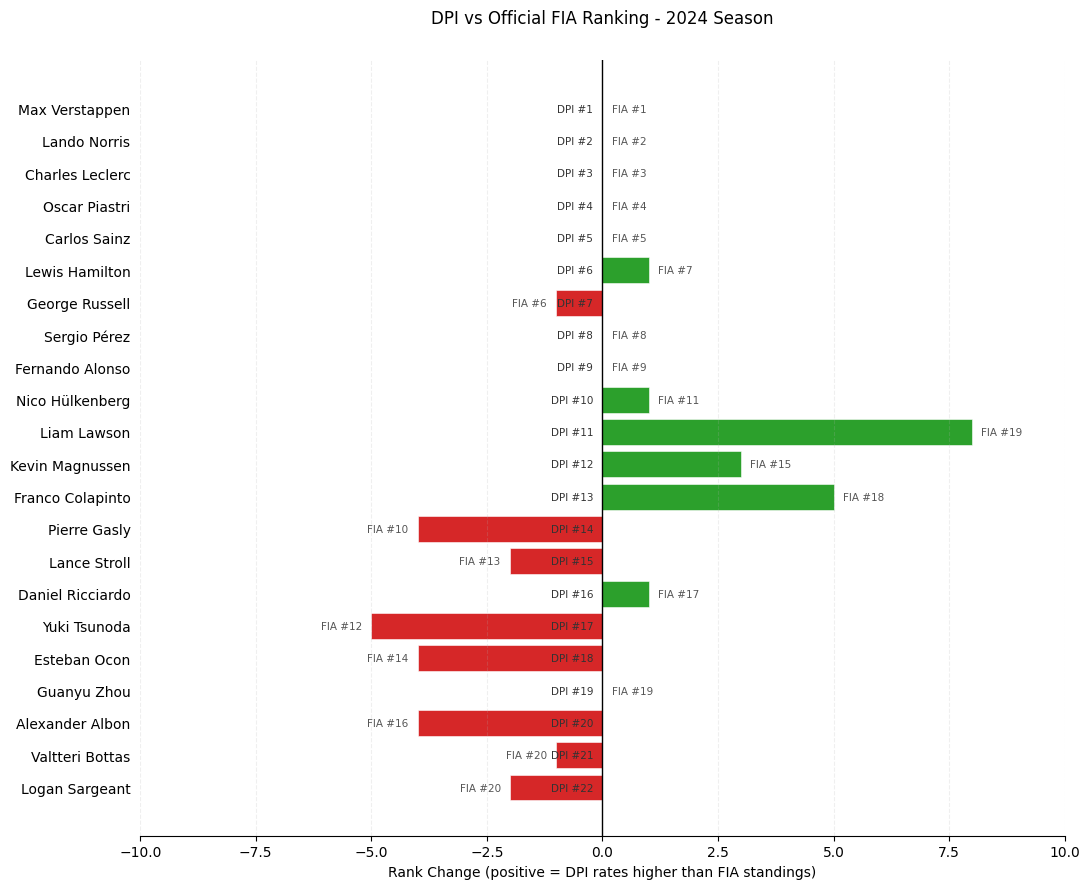

In [59]:
season_2024 = dpi_df[dpi_df['season'] == 2024].copy()
season_2024 = season_2024.sort_values('DPI_rank_season')

season_2024['rank_change'] = (
    season_2024['official_rank'] - season_2024['DPI_rank_season']
)

colours = ['#2ca02c' if x > 0 else '#d62728' if x < 0 else '#aaaaaa'
           for x in season_2024['rank_change']]

fig, ax = plt.subplots(figsize=(11, 9))

bars = ax.barh(
    season_2024['driver_name'],
    season_2024['rank_change'],
    color=colours,
    edgecolor='white',
    linewidth=0.4
)

ax.axvline(0, color='black', linewidth=1)

for i, (_, row) in enumerate(season_2024.iterrows()):
    ax.text(-0.2, i,
            f"DPI #{int(row['DPI_rank_season'])}",
            ha='right', va='center',
            fontsize=7.5, color='#333333')
    xpos = row['rank_change'] + (0.2 if row['rank_change'] >= 0 else -0.2)
    ha   = 'left' if row['rank_change'] >= 0 else 'right'
    ax.text(xpos, i,
            f"FIA #{int(row['official_rank'])}",
            ha=ha, va='center',
            fontsize=7.5, color='#555555')

ax.invert_yaxis()
ax.set_xlabel('Rank Change (positive = DPI rates higher than FIA standings)',
              fontsize=10)
ax.set_title(
    'DPI vs Official FIA Ranking - 2024 Season\n',
    fontsize=12, pad=12
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(axis='x', alpha=0.2, linestyle='--')
ax.tick_params(left=False)
ax.set_xlim(-10, 10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dpi_vs_fia_rank_2024.png',
            dpi=200, bbox_inches='tight')
plt.show()

### What this chart shows

Every driver in the 2024 season ordered by DPI rank. The bar shows how many places the DPI rank differs from the official FIA championship rank. Green bars mean the DPI rates that driver higher than their points total suggests. Red bars mean the DPI rates them lower.

The top six drivers, Verstappen, Norris, Leclerc, Piastri, Sainz and Hamilton, show zero divergence. The DPI and official standings completely agree on who the best drivers were in 2024. The disagreements 
appear further down the grid where points totals are smaller and a single good or bad run of results has a bigger proportional impact.

Liam Lawson is the most striking case, the DPI places him 8 positions higher than the official standings. He only drove 6 races as a substitute at RB but his per-race metrics were strong enough to rank him significantly 
higher by a multi-dimensional measure than his limited points total would suggest. Yuki Tsunoda shows the opposite pattern FIA 12th but DPI 17th reflecting inconsistent finishing and a high DNF rate that the index penalises but that points do not capture.

## Chart 10 - Norris 2024 Lap Time Analysis (OpenF1)

A lap-by-lap pace comparison between Norris and the field average 
during the 2024 British Grand Prix — a race where Norris won in a 
competitive but not dominant McLaren. This contrasts with the 
Verstappen 2023 Bahrain analysis, showing a driver extracting strong 
pace in a car that was genuinely challenged by other teams.

In [60]:
sessions_2024 = openf1_get('sessions', params={
    'year'         : 2024,
    'session_type' : 'Race',
    'country_name' : 'United Kingdom'
})

print("Sessions found:")
for s in sessions_2024:
    print(s)

Sessions found:
{'session_key': 9558, 'session_type': 'Race', 'session_name': 'Race', 'date_start': '2024-07-07T14:00:00+00:00', 'date_end': '2024-07-07T16:00:00+00:00', 'meeting_key': 1240, 'circuit_key': 2, 'circuit_short_name': 'Silverstone', 'country_key': 2, 'country_code': 'GBR', 'country_name': 'United Kingdom', 'location': 'Silverstone', 'gmt_offset': '01:00:00', 'year': 2024, 'is_cancelled': False}


In [61]:
SESSION_KEY_NOR = 9558

laps_nor_raw = openf1_get('laps', params={'session_key': SESSION_KEY_NOR})
laps_nor     = pd.DataFrame(laps_nor_raw)

drivers_nor  = openf1_get('drivers', params={'session_key': SESSION_KEY_NOR})
drivers_nor_df = pd.DataFrame(drivers_nor)
print(drivers_nor_df[['driver_number', 'full_name', 'team_name']])

    driver_number         full_name        team_name
0               1    Max VERSTAPPEN  Red Bull Racing
1               2    Logan SARGEANT         Williams
2               3  Daniel RICCIARDO               RB
3               4      Lando NORRIS          McLaren
4              10      Pierre GASLY           Alpine
5              11      Sergio PEREZ  Red Bull Racing
6              14   Fernando ALONSO     Aston Martin
7              16   Charles LECLERC          Ferrari
8              18      Lance STROLL     Aston Martin
9              20   Kevin MAGNUSSEN     Haas F1 Team
10             22      Yuki TSUNODA               RB
11             23   Alexander ALBON         Williams
12             24       ZHOU Guanyu      Kick Sauber
13             27   Nico HULKENBERG     Haas F1 Team
14             31      Esteban OCON           Alpine
15             44    Lewis HAMILTON         Mercedes
16             55      Carlos SAINZ          Ferrari
17             63    George RUSSELL         Me

In [62]:
laps_nor_clean = laps_nor.copy()
laps_nor_clean = laps_nor_clean.dropna(subset=['lap_duration', 'lap_number'])
laps_nor_clean = laps_nor_clean[laps_nor_clean['lap_duration'] > 85]
laps_nor_clean = laps_nor_clean[laps_nor_clean['lap_duration'] < 130]
laps_nor_clean = laps_nor_clean[laps_nor_clean['lap_number'] > 1]

print("Clean laps shape:", laps_nor_clean.shape)
print("Lap range:", laps_nor_clean['lap_number'].min(),
      "to", laps_nor_clean['lap_number'].max())
print("\nDrivers:", sorted(laps_nor_clean['driver_number'].unique()))

Clean laps shape: (941, 16)
Lap range: 2 to 52

Drivers: [1, 2, 3, 4, 11, 14, 16, 18, 20, 22, 23, 24, 27, 31, 44, 55, 63, 77, 81]


In [63]:
NOR_NUM = 4

nor_all_laps = laps_nor[laps_nor['driver_number'] == NOR_NUM].copy()
nor_pit_out  = nor_all_laps[nor_all_laps['is_pit_out_lap'] == True]['lap_number'].tolist()
nor_pit_in   = [x - 1 for x in nor_pit_out]
nor_pit_all  = nor_pit_out + nor_pit_in

print("Norris pit out laps:", nor_pit_out)
print("Norris pit in laps:", nor_pit_in)

nor_laps = laps_nor_clean[
    (laps_nor_clean['driver_number'] == NOR_NUM) &
    (~laps_nor_clean['lap_number'].isin(nor_pit_all))
].copy()
nor_laps = nor_laps.sort_values('lap_number')

field_nor = (
    laps_nor_clean[
        (laps_nor_clean['driver_number'] != NOR_NUM) &
        (~laps_nor_clean['lap_number'].isin(nor_pit_all))
    ]
    .groupby('lap_number')['lap_duration']
    .median()
    .reset_index()
    .rename(columns={'lap_duration': 'field_median'})
)

merged_nor = nor_laps.merge(field_nor, on='lap_number', how='inner')
merged_nor['gap_to_field'] = merged_nor['field_median'] - merged_nor['lap_duration']

print(f"\nNorris average lap:  {nor_laps['lap_duration'].mean():.3f}s")
print(f"Field median average: {field_nor['field_median'].mean():.3f}s")
print(f"Average gap per lap:  {merged_nor['gap_to_field'].mean():.3f}s faster")
print(f"Norris faster laps:   {(merged_nor['gap_to_field'] > 0).sum()}")
print(f"Field faster laps:    {(merged_nor['gap_to_field'] < 0).sum()}")

Norris pit out laps: [28, 40]
Norris pit in laps: [27, 39]

Norris average lap:  94.042s
Field median average: 95.113s
Average gap per lap:  1.071s faster
Norris faster laps:   43
Field faster laps:    4


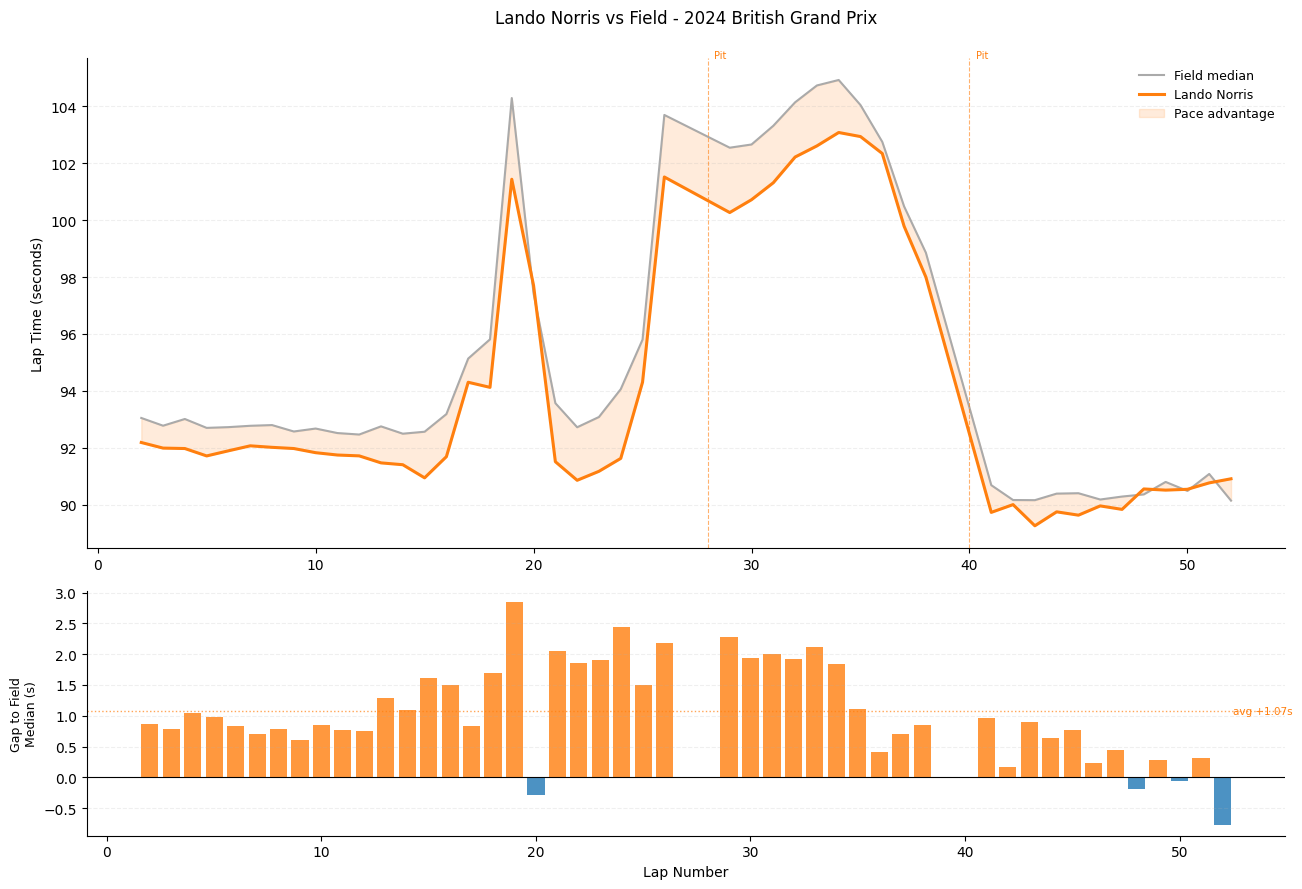

In [65]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9),
                                gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(field_nor['lap_number'], field_nor['field_median'],
         color='#aaaaaa', linewidth=1.5, label='Field median', zorder=2)

ax1.plot(merged_nor['lap_number'], merged_nor['lap_duration'],
         color='#ff7f0e', linewidth=2.2, label='Lando Norris', zorder=3)

ax1.fill_between(
    merged_nor['lap_number'],
    merged_nor['lap_duration'],
    merged_nor['field_median'],
    alpha=0.15, color='#ff7f0e', label='Pace advantage'
)

for pit in nor_pit_out:
    ax1.axvline(pit, color='#ff7f0e', linewidth=0.8,
                linestyle='--', alpha=0.6)
    ax1.text(pit + 0.3, ax1.get_ylim()[1] if ax1.get_ylim()[1] < 130 else 92,
             'Pit', fontsize=7, color='#ff7f0e')

ax1.set_ylabel('Lap Time (seconds)', fontsize=10)
ax1.set_title(
    'Lando Norris vs Field - 2024 British Grand Prix\n',
    fontsize=12, pad=10
)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.2, linestyle='--')
ax1.legend(fontsize=9, frameon=False)


ax2.bar(merged_nor['lap_number'], merged_nor['gap_to_field'],
        color=merged_nor['gap_to_field'].apply(
            lambda x: '#ff7f0e' if x > 0 else '#1f77b4'),
        width=0.8, alpha=0.8)

ax2.axhline(0, color='black', linewidth=0.8)
ax2.axhline(merged_nor['gap_to_field'].mean(),
            color='#ff7f0e', linewidth=1,
            linestyle=':', alpha=0.7)
ax2.text(merged_nor['lap_number'].max() + 0.5,
         merged_nor['gap_to_field'].mean(),
         f"avg +{merged_nor['gap_to_field'].mean():.2f}s",
         fontsize=7.5, color='#ff7f0e', va='center')

ax2.set_xlabel('Lap Number', fontsize=10)
ax2.set_ylabel('Gap to Field\nMedian (s)', fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'norris_2024_british_gp_lap_analysis.png',
            dpi=200, bbox_inches='tight')
plt.show()

### What this chart shows

Norris averaged 1.07 seconds per lap faster than the field median across 43 of 47 comparable racing laps. The large spikes in both lines 
around laps 19 to 22 and laps 25 to 38 reflect the safety car and virtual safety car periods during the 2024 British Grand Prix, one of 
the most chaotic races of that season. Despite the disruption Norris maintained his pace advantage consistently across all three stints.

Compared to the Verstappen 2023 Bahrain analysis, the gap per lap is smaller (1.07s vs 1.38s) and the field median is closer to Norris 
throughout. This reflects the difference between a dominant car and a competitive one. Verstappen's Red Bull in 2023 was in a different 
category to the rest of the field. Norris's McLaren in 2024 was fast but genuinely challenged by Ferrari and Red Bull throughout the season.The fact that Norris still averaged over a second per lap faster than the field median in this race, and scored a DPI of 0.666 for the full season, confirms the index is capturing real driver pace in a car that was not simply running away from the competition.